**Analisis Sentimen Berbasis Aspek dan Pemeringkatan Restoran di Surabaya Menggunakan IndoBERT dan Ulasan Google Maps**

KELOMPOK 7
Anngota:

Ilham Rizky Handriansyah (163231005), Josua Robert Tambupolon (1632310), Bagas Pamungkas (1632310)

**IMPORT LIBRARY**

In [ ]:
import pandas as pd
import numpy as np
import re

**LOAD DATASET**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/STKI/Dataset/Dataset fix/master_reviews (1).csv")

print(df.head())
print(df.columns)

                           restaurant_name  \
0  A&W Maspion Square - A&W Maspion Square   
1  A&W Maspion Square - A&W Maspion Square   
2  A&W Maspion Square - A&W Maspion Square   
3  A&W Maspion Square - A&W Maspion Square   
4  A&W Maspion Square - A&W Maspion Square   

                                         review_text    review_date  \
0  Saya puas sekali dengan pelayanan restorannya....  seminggu lalu   
1               Pelayanan nya keren, makanannya enak  seminggu lalu   
2  Tempat nya bagus , bersih + menunya juga enak ...  2 minggu lalu   
3  restorannya bersih karyawannya sigap cepat dan...  2 minggu lalu   
4                                          ternyaman  2 minggu lalu   

                reviewer_name  
0                 Fahmi Akbar  
1  EZAR ISLAMEY BAGUS SYARIFQ  
2          Claudio Calvintino  
3              Sadam Alamsyah  
4                 lalu Fathul  
Index(['restaurant_name', 'review_text', 'review_date', 'reviewer_name'], dtype='object')


**CLEANING**

In [ ]:
def clean_text(text):

    text = str(text)

    text = text.lower()

    # hapus URL
    text = re.sub(r"http\S+", "", text)

    # hapus www
    text = re.sub(r"www\S+", "", text)

    # hapus emoji
    text = re.sub(
        r'[\U00010000-\U0010ffff]',
        '',
        text
    )

    # sisakan huruf angka dan spasi
    text = re.sub(
        r'[^a-zA-Z0-9\s]',
        ' ',
        text
    )

    # rapikan spasi
    text = re.sub(
        r'\s+',
        ' ',
        text
    )

    return text.strip()

**Hapus Data Sampah**

In [ ]:
# Menghapus data yang tidak memiliki teks ulasan (missing value)
df = df.dropna(
    subset=['review_text']
)


# Menghapus entri hasil salinan/duplikasi berdasarkan nama restoran
df = df[
    ~df['restaurant_name']
    .str.lower()
    .str.contains(
        'salinan',
        na=False
    )
]

# Menghapus baris yang berisi nama kolom akibat kesalahan pembacaan data
df = df[
    df['restaurant_name']
    .str.lower()
    != 'restaurant_name'
]

In [ ]:
# Melakukan preprocessing teks ulasan menggunakan fungsi clean_text
# dan menyimpan hasil pembersihan pada kolom clean_review
df['clean_review'] = df['review_text'].apply(
    clean_text
)

In [ ]:
# Menghapus data ulasan yang terlalu pendek
# dengan panjang karakter kurang dari atau sama dengan 3
df = df[
    df['clean_review'].str.len() > 3
]

In [ ]:
# Menampilkan informasi struktur dataset
# seperti jumlah data, tipe data, dan missing value
print(df.info())

print()

# Menampilkan 5 baris pertama dataset
# untuk melihat hasil preprocessing
print(df.head())

print()

# Menampilkan jumlah total data ulasan
print(
    "Jumlah review:",
    len(df)
)

<class 'pandas.core.frame.DataFrame'>
Index: 5951 entries, 0 to 6770
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   restaurant_name  5951 non-null   object
 1   review_text      5951 non-null   object
 2   review_date      5951 non-null   object
 3   reviewer_name    5950 non-null   object
 4   clean_review     5951 non-null   object
dtypes: object(5)
memory usage: 279.0+ KB
None

                           restaurant_name  \
0  A&W Maspion Square - A&W Maspion Square   
1  A&W Maspion Square - A&W Maspion Square   
2  A&W Maspion Square - A&W Maspion Square   
3  A&W Maspion Square - A&W Maspion Square   
4  A&W Maspion Square - A&W Maspion Square   

                                         review_text    review_date  \
0  Saya puas sekali dengan pelayanan restorannya....  seminggu lalu   
1               Pelayanan nya keren, makanannya enak  seminggu lalu   
2  Tempat nya bagus , bersih + menunya juga en

In [ ]:
#Simpan Dataset bersih
df.to_csv(
    "clean_reviews.csv",
    index=False
)

In [ ]:
print(df.info())

print(df.head())

print(len(df))

<class 'pandas.core.frame.DataFrame'>
Index: 5951 entries, 0 to 6770
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   restaurant_name  5951 non-null   object
 1   review_text      5951 non-null   object
 2   review_date      5951 non-null   object
 3   reviewer_name    5950 non-null   object
 4   clean_review     5951 non-null   object
dtypes: object(5)
memory usage: 279.0+ KB
None
                           restaurant_name  \
0  A&W Maspion Square - A&W Maspion Square   
1  A&W Maspion Square - A&W Maspion Square   
2  A&W Maspion Square - A&W Maspion Square   
3  A&W Maspion Square - A&W Maspion Square   
4  A&W Maspion Square - A&W Maspion Square   

                                         review_text    review_date  \
0  Saya puas sekali dengan pelayanan restorannya....  seminggu lalu   
1               Pelayanan nya keren, makanannya enak  seminggu lalu   
2  Tempat nya bagus , bersih + menunya juga ena

**Exploratory Data Analysis**

In [ ]:
# Jumlah restoran
print("Jumlah restoran unik:")
print(df['restaurant_name'].nunique())

Jumlah restoran unik:
30


In [ ]:
# Distribusi Review per Restoran
review_count = (
    df['restaurant_name']
    .value_counts()
    .reset_index()
)

review_count.columns = [
    'restaurant_name',
    'jumlah_review'
]

display(review_count)

,restaurant_name,jumlah_review
0,Depot Slamet - Depot Slamet,200
1,Soto Madura Wawan - Soto Madura Wawan,200
2,Ayam Bakar Primarasa Ahmad Yani - Ayam Bakar P...,199
3,Urban Wagyu - Urban Wagyu,199
4,Aiola Eatery - Slamet - Aiola Eatery - Slamet,199
5,Arumanis Restaurant - Arumanis Restaurant,199
6,Citilites Skyclub & Bistro - Citilites Skyclub...,199
7,Steak Hut Manyar Kertoarjo - Steak Hut Manyar ...,199
8,Chao Phraya Thai Fine Cuisine - Chao Phraya Th...,199
9,Lin's Garden Restaurant - Lin's Garden Restaurant,199


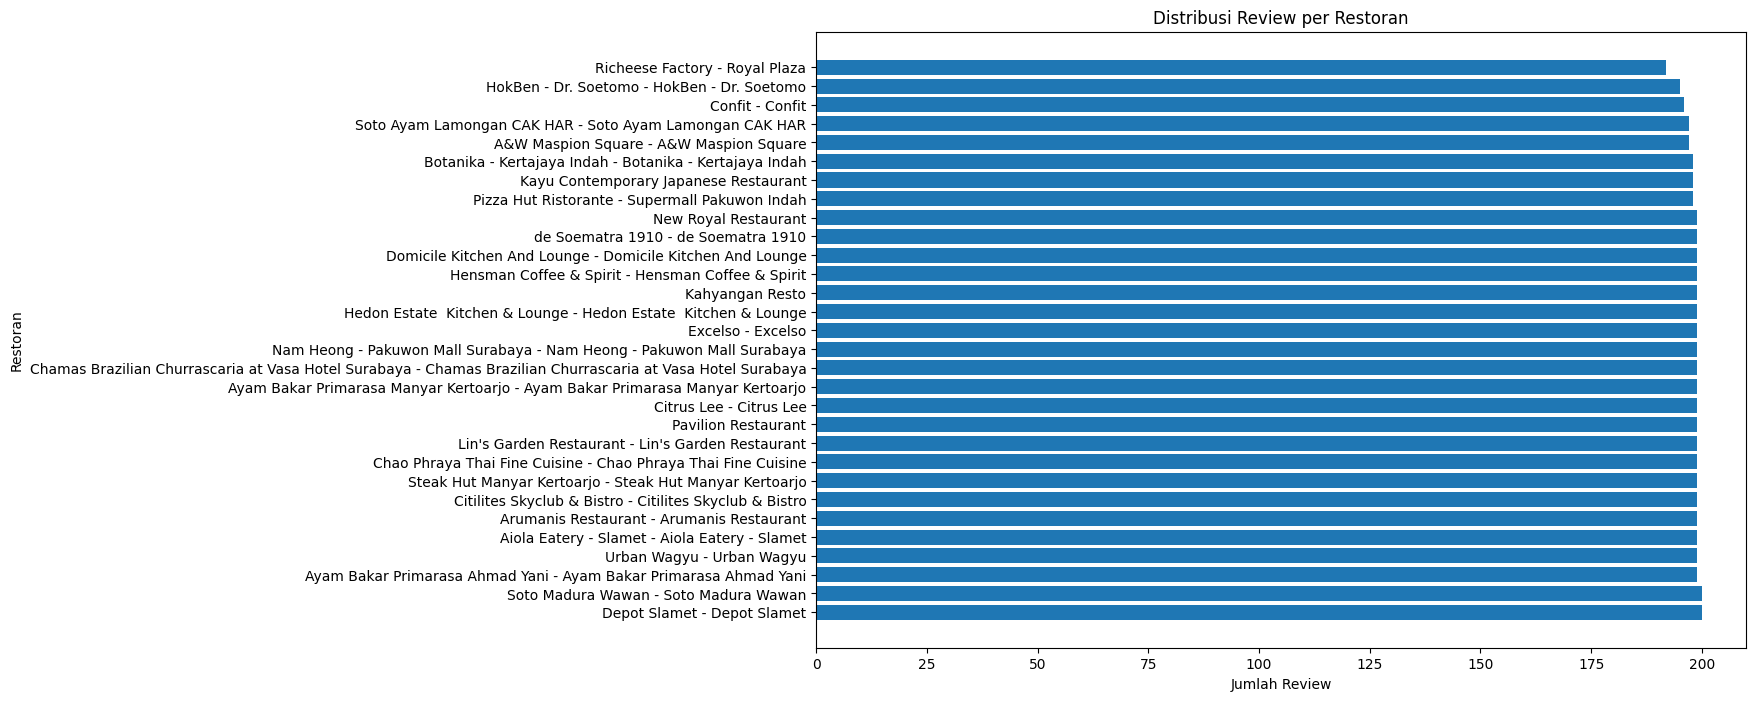

In [ ]:
# Visualisasi Jumlah Review
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.barh(
    review_count['restaurant_name'],
    review_count['jumlah_review']
)

plt.xlabel("Jumlah Review")
plt.ylabel("Restoran")
plt.title("Distribusi Review per Restoran")

plt.show()

In [ ]:
df['review_length'] = (
    df['clean_review']
    .apply(lambda x: len(x.split()))
)

/tmp/ipykernel_4022/4040330074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['review_length'] = (


In [ ]:
# Statistik Panjang Review
print(df['review_length'].describe())

count    5951.00000
mean       19.49017
std        12.73684
min         1.00000
25%         9.00000
50%        17.00000
75%        29.00000
max        63.00000
Name: review_length, dtype: float64


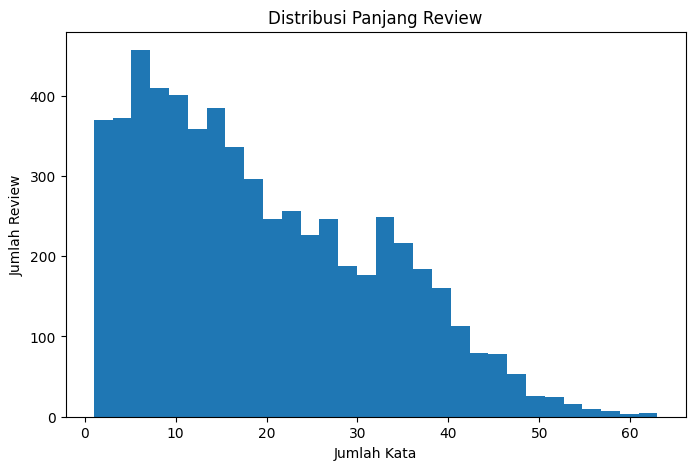

In [ ]:
# Histogram Panjang Review
plt.figure(figsize=(8,5))

plt.hist(
    df['review_length'],
    bins=30
)

plt.xlabel("Jumlah Kata")
plt.ylabel("Jumlah Review")
plt.title("Distribusi Panjang Review")

plt.show()

**DESAIN ABSA**

In [ ]:
# Aspek yang Digunakan
aspect_keywords = {

    "FOOD":[
        "makanan",
        "menu",
        "rasa",
        "enak",
        "lezat",
        "porsi",
        "minuman",
        "steak",
        "daging",
        "sambal"
    ],

    "SERVICE":[
        "pelayanan",
        "pelayan",
        "staff",
        "karyawan",
        "kasir",
        "ramah",
        "sigap",
        "waiter"
    ],

    "PRICE":[
        "harga",
        "murah",
        "mahal",
        "worth",
        "promo",
        "diskon"
    ],

    "ATMOSPHERE":[
        "suasana",
        "cozy",
        "nyaman",
        "view",
        "ambience",
        "nongkrong",
        "estetik",
        "aesthetic"
    ],

    "FACILITY":[
        "toilet",
        "parkir",
        "wifi",
        "ac",
        "mushola",
        "playground"
    ]

}

In [ ]:
# Fungsi untuk mengidentifikasi aspek yang muncul dalam sebuah ulasan
def get_aspects(text):
def get_aspects(text):
  # Memecah teks menjadi daftar kata (token)
    tokens = text.split()
 # Menyimpan aspek yang terdeteksi
    aspects = []
# Memeriksa setiap aspek dan kata kuncinya
    for aspect, keywords in aspect_keywords.items():

        # Jika salah satu kata kunci ditemukan dalam token,
        # maka aspek tersebut ditambahkan ke daftar aspek
        if any(
            word in tokens
            for word in keywords
        ):

            aspects.append(aspect)
# Mengembalikan daftar aspek yang berhasil diidentifikasi
    return aspects

In [ ]:
# Generate Dataset ABSA
rows = []
# Melakukan iterasi pada setiap baris data ulasan
for _, row in df.iterrows():
# Mengidentifikasi aspek yang terdapat pada ulasan
    aspects = get_aspects(
        row['clean_review']
    )
   # Menambahkan setiap aspek yang ditemukan
    # ke dalam list rows
    for aspect in aspects:

        rows.append({

            # Menyimpan nama restoran
            "restaurant_name":
            row['restaurant_name'],
  # Menyimpan teks ulasan yang telah dibersihkan
            "review_text":
            row['clean_review'],
 # Menyimpan aspek yang berhasil diidentifikasi
            "aspect":
            aspect

        })
# Mengubah list hasil ekstraksi menjadi DataFrame baru
absa_df = pd.DataFrame(rows)

In [ ]:
print(absa_df.head())

print()

print("Jumlah data ABSA:")
print(len(absa_df))

                           restaurant_name  \
0  A&W Maspion Square - A&W Maspion Square   
1  A&W Maspion Square - A&W Maspion Square   
2  A&W Maspion Square - A&W Maspion Square   
3  A&W Maspion Square - A&W Maspion Square   
4  A&W Maspion Square - A&W Maspion Square   

                                         review_text   aspect  
0  saya puas sekali dengan pelayanan restorannya ...  SERVICE  
1                pelayanan nya keren makanannya enak     FOOD  
2                pelayanan nya keren makanannya enak  SERVICE  
3  tempat nya bagus bersih menunya juga enak pela...     FOOD  
4  tempat nya bagus bersih menunya juga enak pela...  SERVICE  

Jumlah data ABSA:
6852


**ASPECT EXTRACTION**

In [ ]:
aspect_keywords = {
    'FOOD': [
        'makanan','menu','rasa','burger',
        'ayam','kentang','minuman',
        'es krim','sambal','saus'
    ],

    'SERVICE': [
        'pelayanan','pegawai','kasir',
        'waiter','ramah','cepat',
        'karyawan','staff'
    ],

    'ATMOSPHERE': [
        'tempat','ruangan','parkir',
        'toilet','kursi','meja',
        'ac','suasana'
    ],

    'PRICE': [
        'harga','murah','mahal',
        'worth','promo'
    ],

    'CLEANING': [
        'bersih','kotor',
        'higienis'
    ]
}

In [ ]:
# Fungsi untuk mendeteksi aspek yang terdapat pada teks ulasan
def detect_aspects(text):
# Inisialisasi list untuk menyimpan aspek yang ditemukan
    found_aspects = []
    # Mengubah teks menjadi huruf kecil (lowercase)
    text = text.lower()
    # Melakukan iterasi pada setiap aspek dan kata kuncinya
    for aspect, keywords in aspect_keywords.items():
        # Memeriksa setiap kata kunci pada aspek tersebut
        for word in keywords:

            # Jika kata kunci ditemukan dalam teks,
            # maka aspek ditambahkan ke hasil
            if word in text:

                found_aspects.append(aspect)
                break

    return found_aspects

In [ ]:
df['aspects'] = df['clean_review'].apply(detect_aspects)

/tmp/ipykernel_4022/1372187001.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['aspects'] = df['clean_review'].apply(detect_aspects)


In [ ]:
df[['clean_review','aspects']].head(20)

,clean_review,aspects
0,saya puas sekali dengan pelayanan restorannya ...,[SERVICE]
1,pelayanan nya keren makanannya enak,"[FOOD, SERVICE]"
2,tempat nya bagus bersih menunya juga enak pela...,"[FOOD, SERVICE, ATMOSPHERE, CLEANING]"
3,restorannya bersih karyawannya sigap cepat dan...,"[SERVICE, CLEANING]"
4,ternyaman,[]
5,pelayanan cepat baik,[SERVICE]
6,karyawannya kayak org bingung org pesen apa di...,[SERVICE]
7,tempatnya bersih dan nyaman,"[ATMOSPHERE, CLEANING]"
8,pelayanan mantap,[SERVICE]
9,pelayanannya best,[SERVICE]


In [ ]:
df = df[df['aspects'].str.len()>0]
print(df.shape)

(4634, 7)


In [ ]:
# MEMBUAT DATASET PER-ASPEK
aspect_data = []

for _, row in df.iterrows():

    review = row['clean_review']

    restaurant = row['restaurant_name']

    for aspect in row['aspects']:

        aspect_data.append({
            'restaurant_name': restaurant,
            'review': review,
            'aspect': aspect
        })

In [ ]:
aspect_df = pd.DataFrame(aspect_data)

In [ ]:
aspect_df.head(10)

,restaurant_name,review,aspect
0,A&W Maspion Square - A&W Maspion Square,saya puas sekali dengan pelayanan restorannya ...,SERVICE
1,A&W Maspion Square - A&W Maspion Square,pelayanan nya keren makanannya enak,FOOD
2,A&W Maspion Square - A&W Maspion Square,pelayanan nya keren makanannya enak,SERVICE
3,A&W Maspion Square - A&W Maspion Square,tempat nya bagus bersih menunya juga enak pela...,FOOD
4,A&W Maspion Square - A&W Maspion Square,tempat nya bagus bersih menunya juga enak pela...,SERVICE
5,A&W Maspion Square - A&W Maspion Square,tempat nya bagus bersih menunya juga enak pela...,ATMOSPHERE
6,A&W Maspion Square - A&W Maspion Square,tempat nya bagus bersih menunya juga enak pela...,CLEANING
7,A&W Maspion Square - A&W Maspion Square,restorannya bersih karyawannya sigap cepat dan...,SERVICE
8,A&W Maspion Square - A&W Maspion Square,restorannya bersih karyawannya sigap cepat dan...,CLEANING
9,A&W Maspion Square - A&W Maspion Square,pelayanan cepat baik,SERVICE


In [ ]:
print(aspect_df.shape)

(8397, 3)


**MEMBERI LABEL SENTIMEN (PSEUDO-LABELING)**

In [ ]:
# MEMBERI LABEL SENTIMEN (PSEUDO-LABELING)
positive_words = [
    'enak',
    'lezat',
    'bagus',
    'mantap',
    'ramah',
    'cepat',
    'bersih',
    'nyaman',
    'murah',
    'recommended',
    'suka',
    'puas',
    'top',
    'mantul'
]

negative_words = [
    'mahal',
    'lama',
    'lambat',
    'kotor',
    'buruk',
    'kecewa',
    'parah',
    'dingin',
    'gak enak',
    'tidak enak',
    'mengecewakan'
]

# Fungsi untuk menentukan label sentimen berdasarkan
# jumlah kata positif dan kata negatif pada ulasan
def sentiment_label(text):
 # Mengubah teks menjadi huruf kecil (lowercase)
    text = text.lower()
  # Inisialisasi skor sentimen positif dan negatif
    pos_score = 0
    neg_score = 0
# Menghitung jumlah kata positif yang muncul
    for word in positive_words:

        if word in text:
            pos_score += 1
 # Menghitung jumlah kata negatif yang muncul
    for word in negative_words:

        if word in text:
            neg_score += 1

    # Menentukan label sentimen berdasarkan skor tertinggi
    if pos_score > neg_score:
        return 2

    elif neg_score > pos_score:
        return 0

    else:
        return 1
aspect_df['label'] = aspect_df['review'].apply(sentiment_label)

In [ ]:
aspect_df['label'].value_counts()

,count
label,
2,5526
1,2456
0,415


**SPLIT TRAIN TEST**

In [ ]:
from sklearn.utils import resample
from sklearn.model_selection import train_test_split

# Menggabungkan informasi aspek dengan teks ulasan
# Format: [aspek] isi ulasan
aspect_df['input_text'] = (
    '[' +
    aspect_df['aspect'] +
    '] ' +
    aspect_df['review']
)
# Membagi dataset menjadi data latih (80%)
# dan data uji (20%)
train_texts, test_texts, train_labels, test_labels = train_test_split(

    aspect_df['input_text'],
    aspect_df['label'],

    test_size=0.2,
    random_state=42,
    # Menjaga proporsi setiap kelas sentimen
    # tetap seimbang pada data latih dan data uji
    stratify=aspect_df['label']
)

In [ ]:
print(len(train_texts))
print(len(test_texts))

6717
1680


**MEMBUAT ASPEK DATASET**

In [ ]:
ASPEK = [
    "FOOD",
    "SERVICE",
    "PRICE",
    "ATMOSPHERE",
    "CLEANING"
]

sample_df = df.sample(500, random_state=42)

sample_df.to_csv("aspect_labeling.csv", index=False)


**Semi-Automatic Labeling weak supervision**

In [ ]:
food_keywords = [
    "makanan",
    "menu",
    "ayam",
    "burger",
    "nasi",
    "minuman",
    "rasa",
    "enak"
]

service_keywords = [
    "pelayanan",
    "pegawai",
    "kasir",
    "waiter",
    "cepat",
    "ramah"
]

price_keywords = [
    "harga",
    "murah",
    "mahal"
]

place_keywords = [
    "tempat",
    "parkir",
    "suasana",
    "nyaman"
]

clean_keywords = [
    "bersih",
    "kotor",
    "rapi"
]

In [ ]:
# Fungsi untuk memberikan label pada setiap aspek
# berdasarkan keberadaan kata kunci dalam teks ulasan
def label_aspect(text):
 # Mengubah input menjadi tipe string
    text = str(text)
 # Mengecek keberadaan kata kunci aspek makanan
    makanan = int(any(k in text for k in food_keywords))
  # Mengecek keberadaan kata kunci aspek pelayanan
    pelayanan = int(any(k in text for k in service_keywords))
   # Mengecek keberadaan kata kunci aspek harga
    harga = int(any(k in text for k in price_keywords))
     # Mengecek keberadaan kata kunci aspek tempat
    tempat = int(any(k in text for k in place_keywords))
      # Mengecek keberadaan kata kunci aspek kebersihan
    kebersihan = int(any(k in text for k in clean_keywords))

    return pd.Series([
        makanan,
        pelayanan,
        harga,
        tempat,
        kebersihan
    ])

In [ ]:
df[
    ["makanan",
     "pelayanan",
     "harga",
     "tempat",
     "kebersihan"]
] = df["clean_review"].apply(label_aspect)

In [ ]:
df.head()

,restaurant_name,review_text,review_date,reviewer_name,clean_review,review_length,aspects,makanan,pelayanan,harga,tempat,kebersihan
0,A&W Maspion Square - A&W Maspion Square,Saya puas sekali dengan pelayanan restorannya....,seminggu lalu,Fahmi Akbar,saya puas sekali dengan pelayanan restorannya ...,19,[SERVICE],0,1,0,0,0
1,A&W Maspion Square - A&W Maspion Square,"Pelayanan nya keren, makanannya enak",seminggu lalu,EZAR ISLAMEY BAGUS SYARIFQ,pelayanan nya keren makanannya enak,5,"[FOOD, SERVICE]",1,1,0,0,0
2,A&W Maspion Square - A&W Maspion Square,"Tempat nya bagus , bersih + menunya juga enak ...",2 minggu lalu,Claudio Calvintino,tempat nya bagus bersih menunya juga enak pela...,10,"[FOOD, SERVICE, ATMOSPHERE, CLEANING]",1,1,0,1,1
3,A&W Maspion Square - A&W Maspion Square,restorannya bersih karyawannya sigap cepat dan...,2 minggu lalu,Sadam Alamsyah,restorannya bersih karyawannya sigap cepat dan...,7,"[SERVICE, CLEANING]",0,1,0,0,1
5,A&W Maspion Square - A&W Maspion Square,"pelayanan cepat, baik",2 minggu lalu,nonsuch ending,pelayanan cepat baik,3,[SERVICE],0,1,0,0,0


**Training Aspect Classification dengan IndoBERT**

In [ ]:
pip install transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.3 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer

#Load IndoBERT:
MODEL_NAME = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# Label matrix
labels = df[
    [
        "makanan",
        "pelayanan",
        "harga",
        "tempat",
        "kebersihan"
    ]
].values

In [ ]:
# Melakukan tokenisasi terhadap seluruh teks ulasan
# menggunakan tokenizer dari model BERT
#Tokenization
encodings = tokenizer(
    df["clean_review"].tolist(),
    # Memotong teks yang melebihi panjang maksimum
    truncation=True,
    # Menambahkan padding agar seluruh input
    # memiliki panjang yang sama
    padding=True,
    # Menetapkan panjang maksimum token sebesar 128
    max_length=128
)

In [ ]:
# Dataset Class
import torch
# Membuat kelas dataset untuk data aspek
class AspectDataset(torch.utils.data.Dataset):
 # Konstruktor untuk menginisialisasi data encoding dan label
    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels
   # Mengambil satu data berdasarkan indeks tertentu
    def __getitem__(self, idx):
    # Mengubah setiap hasil encoding menjadi tensor PyTorch
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        # Menambahkan label ke dalam item
        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.float
        )

        return item

    def __len__(self):

        return len(self.labels)

In [ ]:
# buat dataset
dataset = AspectDataset(
    encodings,
    labels
)

**Fine-Tuning IndoBERT untuk Aspect Classification (Multi-Label Classification).**

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["clean_review"],
    labels,
    test_size=0.2,
    random_state=42
)
# Tokenisasi Train dan Test
train_encodings = tokenizer(
    train_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)
# Dataset PyTorch
train_dataset = AspectDataset(
    train_encodings,
    train_labels
)

test_dataset = AspectDataset(
    test_encodings,
    test_labels
)
# Load IndoBERT Multi-Label Model
# Menentukan jumlah label/aspek yang akan diprediksi
NUM_LABELS = 5

from transformers import AutoModelForSequenceClassification
# Memuat model IndoBERT untuk klasifikasi multi-label
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
      # Jumlah output label
    num_labels=NUM_LABELS,
      # Menentukan jenis permasalahan sebagai multi-label classification
    problem_type="multi_label_classification"
)


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
pip install evaluate

**METRIK EVALUASI**

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = (logits > 0).astype(int)

    micro_f1 = f1_score(
        labels,
        predictions,
        average="micro"
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    return {
        "micro_f1": micro_f1,
        "macro_f1": macro_f1
    }



**TRAINING ARGUMENT**

In [ ]:
from transformers import TrainingArguments
# # Mendefinisikan konfigurasi proses training
training_args = TrainingArguments(
   # Direktori penyimpanan model dan checkpoint
    output_dir="./aspect_model",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    # Parameter regularisasi untuk mengurangi overfitting
    weight_decay=0.01,

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="micro_f1",

    greater_is_better=True,

    logging_steps=100,

    save_total_limit=1
)

**TRAINER**

In [ ]:
from transformers import Trainer

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

**TRAINING**

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Micro F1,Macro F1
1,0.048837,0.028773,0.994911,0.993359
2,0.017321,0.017052,0.997142,0.995426
3,0.013549,0.015150,0.996825,0.995269


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1392, training_loss=0.05579030941957715, metrics={'train_runtime': 12782.9679, 'train_samples_per_second': 0.87, 'train_steps_per_second': 0.109, 'total_flos': 525790217452104.0, 'train_loss': 0.05579030941957715, 'epoch': 3.0})

In [ ]:
results = trainer.evaluate()

print(results)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Training Loss,Validation Loss,Epoch,Micro F1,Macro F1
0.013549,0.017052,3,0.997142,0.995426


{'eval_loss': 0.01705220527946949, 'eval_micro_f1': 0.9971419498253413, 'eval_macro_f1': 0.9954258431298278}


In [ ]:
# Simpan Model
trainer.save_model("aspect_indobert")

tokenizer.save_pretrained(
    "aspect_indobert"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('aspect_indobert/tokenizer_config.json', 'aspect_indobert/tokenizer.json')

**TESTING MODEL**

In [ ]:
# Testing Model
import torch

aspect_names = [
    "makanan",
    "pelayanan",
    "harga",
    "tempat",
    "kebersihan"
]

def predict_aspect(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    )

    with torch.no_grad():

        outputs = model(**inputs)
    # Mengambil nilai logit hasil prediksi model
    logits = outputs.logits
    # Mengubah logit menjadi label biner (0 atau 1)
    predictions = (logits > 0).int().numpy()[0]

    result = {}
 # Menghubungkan setiap prediksi dengan nama aspeknya
    for i, aspect in enumerate(aspect_names):

        result[aspect] = predictions[i]

    return result


In [ ]:
predict_aspect(
    "Makanannya enak dan tempatnya nyaman"
)

{'makanan': np.int32(1),
 'pelayanan': np.int32(0),
 'harga': np.int32(0),
 'tempat': np.int32(1),
 'kebersihan': np.int32(0)}

In [ ]:
label_map = {
    "negatif":0,
    "netral":1,
    "positif":2
}

In [ ]:
absa_df.head()

,restaurant_name,review_text,aspect
0,A&W Maspion Square - A&W Maspion Square,saya puas sekali dengan pelayanan restorannya ...,SERVICE
1,A&W Maspion Square - A&W Maspion Square,pelayanan nya keren makanannya enak,FOOD
2,A&W Maspion Square - A&W Maspion Square,pelayanan nya keren makanannya enak,SERVICE
3,A&W Maspion Square - A&W Maspion Square,tempat nya bagus bersih menunya juga enak pela...,FOOD
4,A&W Maspion Square - A&W Maspion Square,tempat nya bagus bersih menunya juga enak pela...,SERVICE


In [ ]:
# MEMBUAT INPUT ABSA
absa_df["input_text"] = (
    "aspect: "
    + absa_df["aspect"]
    + " [SEP] "
    + absa_df["review_text"]
)

In [ ]:
# Mengimpor fungsi untuk membagi dataset
from sklearn.model_selection import train_test_split

# Membagi data menjadi data latih (80%) dan data uji (20%)
train_texts, test_texts, train_labels, test_labels = train_test_split(

    # Data input berupa aspek dan teks ulasan
    aspect_df["input_text"],

    # Label sentimen
    aspect_df["label"],

    # Proporsi data uji sebesar 20%
    test_size=0.2,

    # Menjamin hasil pembagian data tetap konsisten
    random_state=42,

    # Mempertahankan distribusi kelas sentimen
    stratify=aspect_df["label"]
)

# Melakukan tokenisasi pada data latih
train_encodings = tokenizer(

    train_texts.tolist(),

    # Memotong token yang melebihi panjang maksimum
    truncation=True,

    # Menambahkan padding agar seluruh input
    # memiliki panjang yang sama
    padding=True,

    # Menentukan panjang maksimum token
    max_length=128
)

# Melakukan tokenisasi pada data uji
test_encodings = tokenizer(

    test_texts.tolist(),

    truncation=True,

    padding=True,

    max_length=128
)

In [ ]:
# =========================
# Kelas Dataset untuk ABSA
# =========================

# Membuat kelas dataset untuk Aspect-Based Sentiment Analysis (ABSA)
class ABSADataset(torch.utils.data.Dataset):

    # Inisialisasi data hasil tokenisasi dan label sentimen
    def __init__(self, encodings, labels):

        self.encodings = encodings
        self.labels = labels

    # Mengambil satu sampel data berdasarkan indeks
    def __getitem__(self, idx):

        # Mengubah hasil tokenisasi menjadi tensor PyTorch
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        # Menambahkan label sentimen ke dalam sampel data
        item["labels"] = torch.tensor(
            self.labels.iloc[idx],
            dtype=torch.long
        )

        return item

    # Mengembalikan jumlah total data dalam dataset
    def __len__(self):

        return len(self.labels)


# Membentuk dataset data latih
train_dataset = ABSADataset(
    train_encodings,
    train_labels
)

# Membentuk dataset data uji
test_dataset = ABSADataset(
    test_encodings,
    test_labels
)

In [ ]:
# Memuat model IndoBERT pre-trained untuk klasifikasi sentimen berbasis aspek
model = AutoModelForSequenceClassification.from_pretrained(

    MODEL_NAME,

    num_labels=3
)

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Mengimpor metrik evaluasi dari scikit-learn
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

# Fungsi untuk menghitung performa model
def compute_metrics(eval_pred):

    # Mengambil nilai logit dan label sebenarnya
    logits, labels = eval_pred

    # Menentukan kelas prediksi berdasarkan
    # nilai logit tertinggi
    predictions = logits.argmax(axis=1)

    # Menghitung nilai akurasi
    accuracy = accuracy_score(
        labels,
        predictions
    )

    # Menghitung Macro F1-Score
    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    # Menghitung Weighted F1-Score
    weighted_f1 = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    # Mengembalikan seluruh metrik evaluasi
    return {

        "accuracy": accuracy,

        "macro_f1": macro_f1,

        "weighted_f1": weighted_f1
    }

In [ ]:
# Mendefinisikan parameter pelatihan model ABSA menggunakan TrainingArguments
training_args = TrainingArguments(

    # Direktori penyimpanan model hasil fine-tuning
    output_dir="./absa_model",

    # Learning rate yang digunakan selama proses optimasi
    learning_rate=2e-5,

    # Ukuran batch pada data pelatihan
    per_device_train_batch_size=8,

    # Ukuran batch pada data evaluasi
    per_device_eval_batch_size=8,

    # Jumlah iterasi pelatihan terhadap seluruh dataset
    num_train_epochs=3,

    # Parameter regularisasi weight decay
    weight_decay=0.01,

    # Evaluasi model dilakukan setiap akhir epoch
    eval_strategy="epoch",

    # Penyimpanan model dilakukan setiap akhir epoch
    save_strategy="epoch",

    # Memuat model dengan performa terbaik setelah pelatihan selesai
    load_best_model_at_end=True,

    # Menggunakan Macro F1-Score sebagai dasar pemilihan model terbaik
    metric_for_best_model="macro_f1",

    # Nilai metrik yang lebih tinggi menunjukkan performa yang lebih baik
    greater_is_better=True
)

In [ ]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.350393,0.150174,0.963690,0.933687,0.963800
2,0.107575,0.099397,0.976190,0.963260,0.976091


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.350393,0.150174,0.963690,0.933687,0.963800
2,0.107575,0.099397,0.976190,0.963260,0.976091
3,0.032950,0.076226,0.983929,0.969653,0.983837


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2520, training_loss=0.14301970573881315, metrics={'train_runtime': 23469.7021, 'train_samples_per_second': 0.859, 'train_steps_per_second': 0.107, 'total_flos': 983769249336930.0, 'train_loss': 0.14301970573881315, 'epoch': 3.0})

In [ ]:
NEGATIF = 0
NETRAL  = 1
POSITIF = 2

In [ ]:
score_map = {
    0: 1,   # negatif
    1: 3,   # netral
    2: 5    # positif
}

In [ ]:
absa_result = aspect_df.rename(columns={'label': 'sentiment'})
absa_result.head()

,restaurant_name,review,aspect,sentiment,input_text
0,A&W Maspion Square - A&W Maspion Square,saya puas sekali dengan pelayanan restorannya ...,SERVICE,2,[SERVICE] saya puas sekali dengan pelayanan re...
1,A&W Maspion Square - A&W Maspion Square,pelayanan nya keren makanannya enak,FOOD,2,[FOOD] pelayanan nya keren makanannya enak
2,A&W Maspion Square - A&W Maspion Square,pelayanan nya keren makanannya enak,SERVICE,2,[SERVICE] pelayanan nya keren makanannya enak
3,A&W Maspion Square - A&W Maspion Square,tempat nya bagus bersih menunya juga enak pela...,FOOD,2,[FOOD] tempat nya bagus bersih menunya juga en...
4,A&W Maspion Square - A&W Maspion Square,tempat nya bagus bersih menunya juga enak pela...,SERVICE,2,[SERVICE] tempat nya bagus bersih menunya juga...


In [ ]:
# KONVERSI SENTIMEN MENJADI SKOR
score_map = {
    0: 1,
    1: 3,
    2: 5
}

absa_result["score"] = (
    absa_result["sentiment"]
    .map(score_map)
)

In [ ]:
# MENGHITUNG RATA-RATA TIAP ASPEK
restaurant_scores = (

    absa_result

    .groupby(
        ["restaurant_name", "aspect"]
    )["score"]

    .mean()

    .reset_index()

)

In [ ]:
# PIVOT TABLE
restaurant_matrix = restaurant_scores.pivot(

    index="restaurant_name",

    columns="aspect",

    values="score"

)

In [ ]:
# MENGISI NILAI YANG HILANG
restaurant_matrix = restaurant_matrix.fillna(3)

**WEIGHTED SUM MODEL**

In [ ]:
# WEIGHTED SUM MODEL
weights = {

    "makanan":0.35,

    "pelayanan":0.25,

    "harga":0.15,

    "tempat":0.15,

    "kebersihan":0.10

}

In [ ]:
# Hitung skor akhir:
restaurant_matrix["final_score"] = (

      restaurant_matrix["FOOD"]
    * weights["makanan"]

    + restaurant_matrix["SERVICE"]
    * weights["pelayanan"]

    + restaurant_matrix["PRICE"]
    * weights["harga"]

    + restaurant_matrix["ATMOSPHERE"]
    * weights["tempat"]

    + restaurant_matrix["CLEANING"]
    * weights["kebersihan"]

)

In [ ]:
# SORTING RANKING
ranking = (

    restaurant_matrix

    .sort_values(
        "final_score",
        ascending=False
    )

)

In [ ]:
ranking.head(30)

aspect,ATMOSPHERE,CLEANING,FOOD,PRICE,SERVICE,final_score
restaurant_name,,,,,,
Pizza Hut Ristorante - Supermall Pakuwon Indah,4.681818,5.000000,4.684211,4.636364,4.584416,4.683305
Hensman Coffee & Spirit - Hensman Coffee & Spirit,4.370079,5.000000,4.666667,4.741935,4.471698,4.618060
Steak Hut Manyar Kertoarjo - Steak Hut Manyar Kertoarjo,4.650485,4.714286,4.545455,4.582090,4.623188,4.603021
Kahyangan Resto,4.393939,5.000000,4.465649,4.200000,4.766667,4.543735
Hedon Estate Kitchen & Lounge - Hedon Estate Kitchen & Lounge,4.328767,5.000000,4.585586,4.111111,4.500000,4.495937
New Royal Restaurant,4.080292,5.000000,4.487179,4.000000,4.743590,4.468454
Pavilion Restaurant,4.583333,4.875000,4.323741,4.000000,4.672727,4.456491
Lin's Garden Restaurant - Lin's Garden Restaurant,4.232323,4.818182,4.500000,4.130435,4.560000,4.451232
A&W Maspion Square - A&W Maspion Square,4.561644,4.813953,4.500000,3.615385,4.544554,4.419088


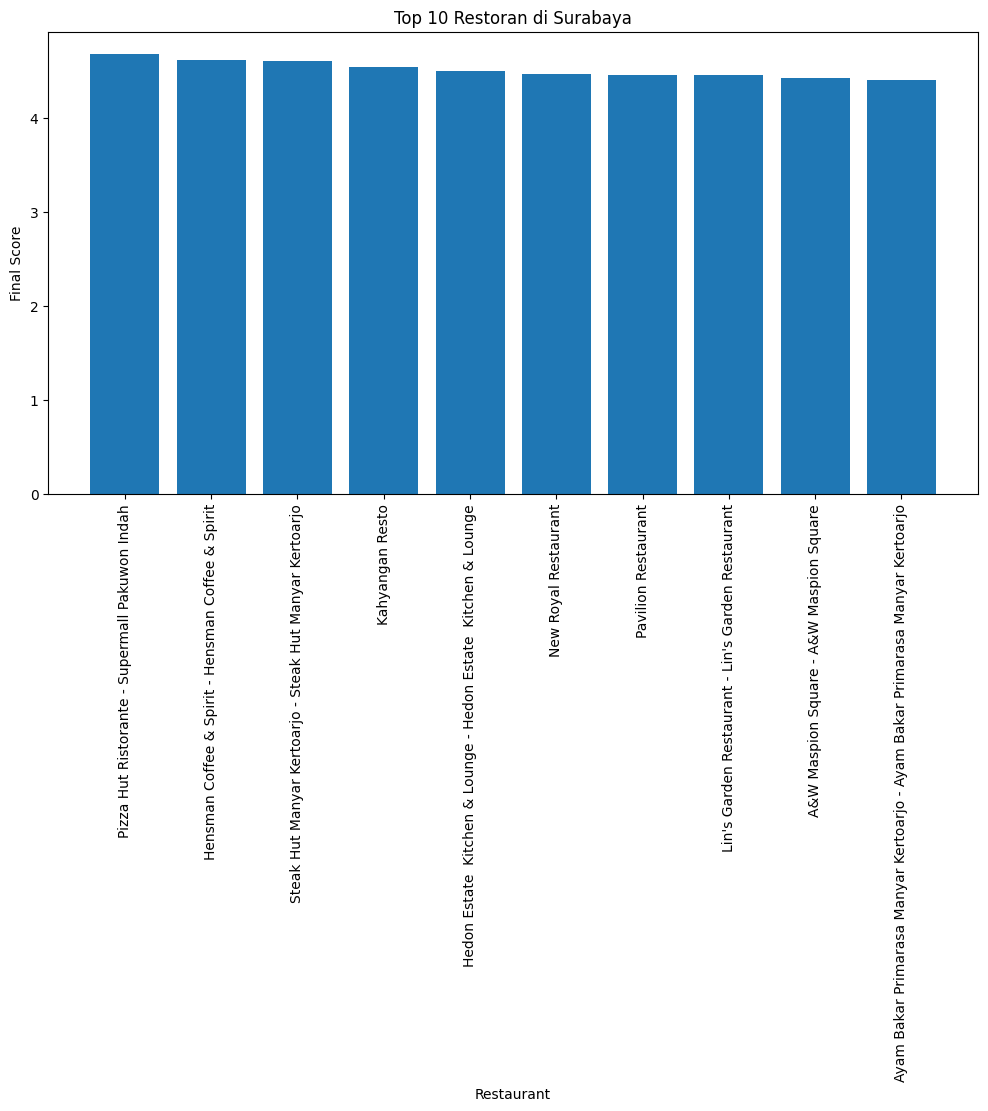

In [ ]:
# VISUALISASI RANKING
import matplotlib.pyplot as plt

top10 = ranking.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10.index,
    top10["final_score"]
)

plt.xticks(rotation=90)

plt.ylabel("Final Score")

plt.xlabel("Restaurant")

plt.title(
    "Top 10 Restoran di Surabaya"
)

plt.show()



In [ ]:
top30 = ranking.head(30)

top30[
    [
        "FOOD",
        "SERVICE",
        "PRICE",
        "ATMOSPHERE",
        "CLEANING"
    ]
]

aspect,FOOD,SERVICE,PRICE,ATMOSPHERE,CLEANING
restaurant_name,,,,,
Pizza Hut Ristorante - Supermall Pakuwon Indah,4.684211,4.584416,4.636364,4.681818,5.000000
Hensman Coffee & Spirit - Hensman Coffee & Spirit,4.666667,4.471698,4.741935,4.370079,5.000000
Steak Hut Manyar Kertoarjo - Steak Hut Manyar Kertoarjo,4.545455,4.623188,4.582090,4.650485,4.714286
Kahyangan Resto,4.465649,4.766667,4.200000,4.393939,5.000000
Hedon Estate Kitchen & Lounge - Hedon Estate Kitchen & Lounge,4.585586,4.500000,4.111111,4.328767,5.000000
New Royal Restaurant,4.487179,4.743590,4.000000,4.080292,5.000000
Pavilion Restaurant,4.323741,4.672727,4.000000,4.583333,4.875000
Lin's Garden Restaurant - Lin's Garden Restaurant,4.500000,4.560000,4.130435,4.232323,4.818182
A&W Maspion Square - A&W Maspion Square,4.500000,4.544554,3.615385,4.561644,4.813953


**MATRIKS HASIL ASPEK**

In [ ]:
from sklearn.metrics import confusion_matrix

# Get predictions from the trainer
predictions_output = trainer.predict(test_dataset)

# Extract logits and convert to class predictions
predictions = predictions_output.predictions.argmax(axis=1)

cm = confusion_matrix(
    test_labels,
    predictions
)

print(cm)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


[[  76    6    1]
 [   2  476   13]
 [   0    5 1101]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        test_labels,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.97      0.92      0.94        83
           1       0.98      0.97      0.97       491
           2       0.99      1.00      0.99      1106

    accuracy                           0.98      1680
   macro avg       0.98      0.96      0.97      1680
weighted avg       0.98      0.98      0.98      1680



**VALIDASI MANUSIA**

In [ ]:
import pandas as pd

validasi_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/STKI/Program/sampel_validasi_manusia - sampel_validasi_manusia(1).csv")

validasi_df.head()

,restaurant_name,review_text,aspect,sentiment,Validasi Manusia
0,Pavilion Restaurant,suasana nyaman pelayan sangat ramah sayang pil...,PRICE,positive,neutral
1,Steak Hut Manyar Kertoarjo - Steak Hut Manyar ...,first of all yg aku notice ukuran daging nya p...,FOOD,neutral,positive
2,Lin's Garden Restaurant - Lin's Garden Restaurant,really nice halal chinese food restaurant food...,SERVICE,neutral,positive
3,Hedon Estate Kitchen & Lounge - Hedon Estate ...,suka tempat dn masakannya jg enak harga relati...,ATMOSPHERE,positive,positive
4,Excelso - Excelso,salah satu pilihan tempat nongkrong di area su...,FACILITY,neutral,positive


In [ ]:
validasi_df["sentiment"].unique()
validasi_df["Validasi Manusia"].unique()

label_map = {
    "positif":"positive",
    "netral":"neutral",
    "negatif":"negative"
}

validasi_df["Validasi Manusia"] = (
    validasi_df["Validasi Manusia"]
    .replace(label_map)
)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_true = validasi_df["Validasi Manusia"]

y_pred = validasi_df["sentiment"]

accuracy = accuracy_score(
    y_true,
    y_pred
)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)

Accuracy: 0.58

Classification Report:

              precision    recall  f1-score   support

    negative       0.57      0.29      0.38        14
     neutral       0.21      0.50      0.29        32
    positive       0.83      0.62      0.71       154

    accuracy                           0.58       200
   macro avg       0.54      0.47      0.46       200
weighted avg       0.72      0.58      0.62       200



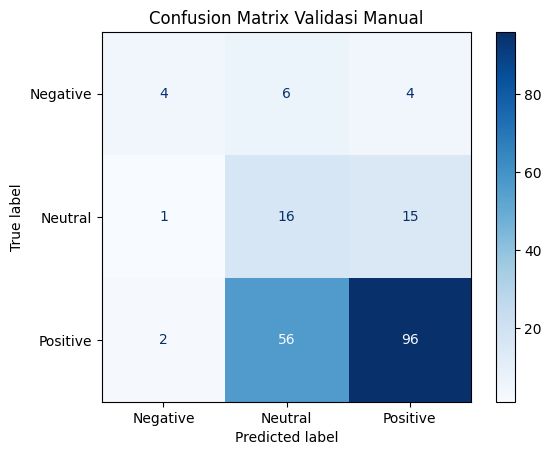

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "negative",
        "neutral",
        "positive"
    ]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

disp.plot(cmap="Blues")

plt.title(
    "Confusion Matrix Validasi Manual"
)

plt.show()

In [ ]:
from sklearn.metrics import cohen_kappa_score

kappa = cohen_kappa_score(
    y_true,
    y_pred
)

print("Cohen Kappa:", kappa)

Cohen Kappa: 0.14703493095044684


In [ ]:
validasi_df[
    validasi_df["sentiment"]
    != validasi_df["Validasi Manusia"]
]

,restaurant_name,review_text,aspect,sentiment,Validasi Manusia
0,Pavilion Restaurant,suasana nyaman pelayan sangat ramah sayang pil...,PRICE,positive,neutral
1,Steak Hut Manyar Kertoarjo - Steak Hut Manyar ...,first of all yg aku notice ukuran daging nya p...,FOOD,neutral,positive
2,Lin's Garden Restaurant - Lin's Garden Restaurant,really nice halal chinese food restaurant food...,SERVICE,neutral,positive
4,Excelso - Excelso,salah satu pilihan tempat nongkrong di area su...,FACILITY,neutral,positive
7,Domicile Kitchen And Lounge - Domicile Kitchen...,taste are delicious and cozy place for hangout...,FACILITY,neutral,positive
...,...,...,...,...,...
188,Arumanis Restaurant - Arumanis Restaurant,arum manis sekarang sangat mengecewakan dan sa...,FACILITY,neutral,negative
189,Steak Hut Manyar Kertoarjo - Steak Hut Manyar ...,makan ditempat malam hari suasananya lokasi da...,FOOD,positive,negative
191,Soto Ayam Lamongan CAK HAR - Soto Ayam Lamonga...,soto ayam lamongan cak har sudah lama dikenal ...,ATMOSPHERE,negative,positive
193,Pavilion Restaurant,good service good dinner or lunch or breakfast...,SERVICE,neutral,positive
